# 1 — Transport Matrix Builder
## Stage 1 · Air Modelling Attribution
> **Model**: `C = T · Q`  
> `C (n_stations,)` — observed concentration vector [µg/m³]  
> `T (n_stations, n_src)` — transport matrix (Gaussian Plume) [µg/m³ per g/s]  
> `Q (n_src,)` — unknown emission rates [g/s]
>
> **References**  
> Seinfeld & Pandis, *Atmospheric Chemistry and Physics*, 3rd ed., 2016  
> Pasquill & Smith, *Atmospheric Diffusion*, 3rd ed., 1983  
> Turner, *Workbook of Atmospheric Dispersion Estimates*, EPA, 1970


---

In [67]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 0 — GLOBAL STYLE CONFIGURATION
# What: One-time matplotlib / seaborn theme applied at notebook launch.
# Why:  Centralising style here means every subsequent plot cell is clean —
#       no repeated rc calls, no copy-pasted color strings.
# ─────────────────────────────────────────────────────────────────────────────

import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
# Seaborn whitegrid as the single source of visual truth
sns.set_theme(
    style="whitegrid",
    palette="muted",
    font="DejaVu Sans",
    font_scale=1.05,
    rc={
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.4,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)
# Palette exported for reuse in downstream cells
PALETTE = sns.color_palette("muted")

In [68]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 1 — IMPORTS & JUPYTER MAGIC
# What: All third-party imports in one place.
# Why:  Fail-fast on missing packages; no import surprises mid-notebook.
# ─────────────────────────────────────────────────────────────────────────────

%load_ext autoreload
%autoreload 2
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import networkx as nx

from tqdm.notebook import tqdm
from IPython.display import display

print("All imports successful.")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
All imports successful.
NumPy  : 2.4.6
Pandas : 3.0.3


In [69]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 — CONFIGURATION (edit here, nowhere else)
# What: All tuneable constants live here — paths, thresholds, pollutant choice.
# Why:  Single source of truth; changing POLLUTANT here ripples everywhere.
# ─────────────────────────────────────────────────────────────────────────────

# Stations excluded from all analysis (persistent data gaps)
EXCLUDE_STATIONS = ["BWSSBKadabesanahalli","CityRailwayStation"]
# File paths
ROOT_DIR = Path().resolve().parents[2]
DATA_DIR = ROOT_DIR / "backend" / "data"
MASTER_DATASET_FILE = DATA_DIR / "artifacts" / "final_master_dataset.csv"
STATIONS_FILE = DATA_DIR / "raw" / "stations.csv"
# Output directory
OUT_DIR = Path().resolve() / "data_prep"
OUT_DIR.mkdir(exist_ok=True)

print("Configuration loaded.")
print(f"Excluded       : {EXCLUDE_STATIONS}")
print(f"Output dir     : {OUT_DIR}")


Configuration loaded.
Excluded       : ['BWSSBKadabesanahalli', 'CityRailwayStation']
Output dir     : /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/data_prep


In [70]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 — LOAD STATION METADATA
# What: Load stations.csv, drop the two problem stations, extract coords.
# Why:  BTMLayout and BWSSBKadabesanahalli have ~35 k missing rows each —
#       including them distorts every pivot and imputation step.
# ─────────────────────────────────────────────────────────────────────────────

stations_raw = pd.read_csv(STATIONS_FILE)
stations_df = (
    stations_raw[~stations_raw["station_name"].isin(EXCLUDE_STATIONS)]
    .copy()
    .reset_index(drop=True)
)

STATION_NAMES = stations_df["station_name"].tolist()
N = len(STATION_NAMES)
LATS = stations_df["latitude"].values
LONS = stations_df["longitude"].values

print("Station metadata loaded.")
print(f"  Total in file   : {len(stations_raw)}")
print(f"  After exclusion : {N}  (dropped {EXCLUDE_STATIONS})")
display(stations_df[["station_name", "latitude", "longitude"]])


Station metadata loaded.
  Total in file   : 14
  After exclusion : 12  (dropped ['BWSSBKadabesanahalli', 'CityRailwayStation'])


,station_name,latitude,longitude
0,BTMLayout,12.913522,77.595080
1,BapujiNagar,12.951913,77.539784
2,Hebbal,13.029152,77.585901
3,HombegowdaNagar,12.938539,77.590100
4,Jayanagar5thBlock,12.920984,77.584908
5,Jigani,12.781628,77.629914
6,KasturiNagar,13.003872,77.664217
7,Peenya,13.027020,77.494094
8,RvceMailasandra,12.921418,77.502466
9,SaneguravaHalli,12.990328,77.543138


In [71]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 4 — GAUSSIAN PLUME PHYSICS CONSTANTS & LOOKUP TABLES
# What: Pasquill-Gifford dispersion coefficients and physical thresholds.
# Why:  All tunable physics in one cell; not buried inside functions.
# References: Turner (1970), Seinfeld & Pandis (2016) Ch. 18
# ─────────────────────────────────────────────────────────────────────────────

# Pasquill-Gifford (P-G) stability classes A (most unstable) → F (most stable)
# σ_y(x) = a_y · x^b_y   [m]
# σ_z(x) = a_z · x^b_z   [m]
PG_COEFFS = {
    "A": dict(a_y=0.36, b_y=0.90, a_z=0.00023, b_z=2.10),
    "B": dict(a_y=0.25, b_y=0.90, a_z=0.058, b_z=1.09),
    "C": dict(a_y=0.19, b_y=0.90, a_z=0.11, b_z=0.91),
    "D": dict(a_y=0.13, b_y=0.90, a_z=0.57, b_z=0.58),
    "E": dict(a_y=0.096, b_y=0.90, a_z=0.85, b_z=0.47),
    "F": dict(a_y=0.063, b_y=0.90, a_z=0.77, b_z=0.42),
}

# Physical floors / caps — empirically validated bounds for P-G applicability
MIN_WIND_SPEED_MS = 0.5  # [m/s]  below this, the plume equation is singular
MIN_DOWNWIND_DIST_M = 500.0  # [m]    P-G calibrated at x ≥ 500 m in field studies
MAX_SIGMA_Z_M = 500.0  # [m]    cap to prevent division underflow in stable runs
H_STACK = 20.0  # effective stack / emission height [m]
MIN_STATIONS = 10  # minimum stations with valid data at a given timestamp

print("P-G coefficient table loaded.")
print(f"  Stability classes : {list(PG_COEFFS.keys())}")
print(f"  Min wind speed    : {MIN_WIND_SPEED_MS} m/s")
print(f"  Min downwind dist : {MIN_DOWNWIND_DIST_M} m")
print(f"  Max sigma_z cap   : {MAX_SIGMA_Z_M} m")
print(f"Stack height   : {H_STACK} m")
print(f"Min stations   : {MIN_STATIONS}")

P-G coefficient table loaded.
  Stability classes : ['A', 'B', 'C', 'D', 'E', 'F']
  Min wind speed    : 0.5 m/s
  Min downwind dist : 500.0 m
  Max sigma_z cap   : 500.0 m
Stack height   : 20.0 m
Min stations   : 10


In [72]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5 — HELPER FUNCTIONS
# What: Reusable geometry and dispersion functions called by the T-matrix builder.
# Why:  Keeps the main loop clean; each function has one job.
# ─────────────────────────────────────────────────────────────────────────────


def haversine_km(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """
    Great-circle distance between two geodetic points [km].
    Formula (Sinnott, 1984):
        a = sin²(Δlat/2) + cos(lat1)·cos(lat2)·sin²(Δlon/2)
        d = 2R · arcsin(√a),  R = 6371 km
    """
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    d_phi = np.radians(lat2 - lat1)
    d_lam = np.radians(lon2 - lon1)
    a = np.sin(d_phi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(d_lam / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def bearing_deg(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """
    Initial bearing (clockwise from North) from point 1 to point 2 [degrees].
    Formula:
        θ = atan2(sin(Δλ)·cos(φ2),  cos(φ1)·sin(φ2) - sin(φ1)·cos(φ2)·cos(Δλ))
        θ_deg = (θ_rad x 180/π) mod 360
    """
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    d_lam = np.radians(lon2 - lon1)
    theta = np.arctan2(
        np.sin(d_lam) * np.cos(phi2),
        np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(d_lam),
    )
    return np.degrees(theta) % 360


def stability_class(
    wind_speed_ms: float, solar_rad_Wm2: float, is_daytime: bool
) -> str:
    """
    Pasquill stability class (A-F) from wind speed, solar radiation and time-of-day.
    Simplified Pasquill-Gifford lookup (Turner, 1970 Table 2-2).
    Returns one of: 'A', 'B', 'C', 'D', 'E', 'F'
    """
    u = wind_speed_ms
    sr = solar_rad_Wm2
    if is_daytime:
        if u < 2:
            return "A" if sr > 600 else ("B" if sr > 300 else "C")
        elif u < 3:
            return "B" if sr > 300 else "C"
        elif u < 5:
            return "C" if sr > 50 else "D"
        else:
            return "D"
    else:
        if u < 2:
            return "F"
        elif u < 3:
            return "E"
        else:
            return "D"


def sigma_y_z(x_m: float, cls: str):
    """
    Pasquill-Gifford lateral and vertical dispersion coefficients [m].

    σ_y(x) = a_y · x^b_y
    σ_z(x) = a_z · x^b_z  (capped at MAX_SIGMA_Z_M for numerical stability)
    """
    c = PG_COEFFS[cls]
    sy = c["a_y"] * x_m ** c["b_y"]
    sz = min(c["a_z"] * x_m ** c["b_z"], MAX_SIGMA_Z_M)
    return sy, sz


def transport_element(
    lat_src: float,
    lon_src: float,
    lat_rec: float,
    lon_rec: float,
    wind_speed_ms: float,
    wind_dir_deg: float,
    stability_cls: str,
    H_m: float = H_STACK,
) -> float:
    """
    Scalar transport coefficient T_{i,j} from source j to receptor i  [µg m⁻³ per g s⁻¹].

    Steps:
      1. Haversine distance d [km] → d_m [m]
      2. Bearing from source to receptor (geographic North = 0°, clockwise)
      3. Decompose into downwind (x) and crosswind (y) distances:
            x = d_m · cos(wind_dir − bearing)   # > 0 → downwind
            y = d_m · sin(wind_dir − bearing)   # lateral offset
      4. x ≤ 0  → receptor is upwind → return 0
      5. Compute σ_y, σ_z from P-G table
      6. Ground-level Gaussian plume formula, scaled 1e6 (g → µg)

    Formula:
      T = 1e6 / (π · u · σ_y · σ_z)
            x exp(−y² / 2σ_y²)
            x exp(−H² / 2σ_z²)
    """
    if not (np.isfinite(wind_speed_ms) and np.isfinite(wind_dir_deg)):
        return 0.0

    u = max(float(wind_speed_ms), MIN_WIND_SPEED_MS)
    d_km = haversine_km(lat_src, lon_src, lat_rec, lon_rec)

    # Diagonal entry: same station → use 100 m proxy (avoids singular T)
    if d_km < 0.01:
        d_km = 0.1
    d_m = d_km * 1000.0

    bear = bearing_deg(lat_src, lon_src, lat_rec, lon_rec)
    delta_rad = np.radians(wind_dir_deg - bear)
    x_m = d_m * np.cos(delta_rad)
    y_m = d_m * np.sin(delta_rad)

    if x_m <= 0 or not (np.isfinite(x_m) and np.isfinite(y_m)):
        return 0.0  # receptor is upwind — no Gaussian contribution

    sy, sz = sigma_y_z(x_m, stability_cls)
    if sy < 1e-6 or sz < 1e-6:
        return 0.0

    lateral = np.exp(-(y_m**2) / (2 * sy**2))
    vertical = np.exp(-(H_m**2) / (2 * sz**2))
    T_raw = (1.0 / (np.pi * u * sy * sz)) * lateral * vertical

    return float(T_raw * 1e6) if np.isfinite(T_raw) else 0.0


In [73]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6 — LOAD RAW DATA
# What: Read master CSV, retain only active stations, show basic shape/types.
# Why:  Up-front visibility of data size and column types catches surprises early.
# ─────────────────────────────────────────────────────────────────────────────
print("Loading dataset from :",MASTER_DATASET_FILE)
df_raw = pd.read_csv(MASTER_DATASET_FILE, parse_dates=["time"])

# Restrict to active stations only
df_raw = df_raw[df_raw["station_name"].isin(STATION_NAMES)].copy()
df_raw = df_raw.sort_values(["time", "station_name"]).reset_index(drop=True)

print("Raw data loaded.")
print(f"Shape : {df_raw.shape}")
print(f"Time  : {df_raw['time'].min()}  →  {df_raw['time'].max()}")

Loading dataset from : /home/srirama/Documents/sr_proj/AirModeling/backend/data/artifacts/final_master_dataset.csv
Raw data loaded.
Shape : (420480, 25)
Time  : 2025-01-01 00:00:00  →  2025-12-31 23:45:00


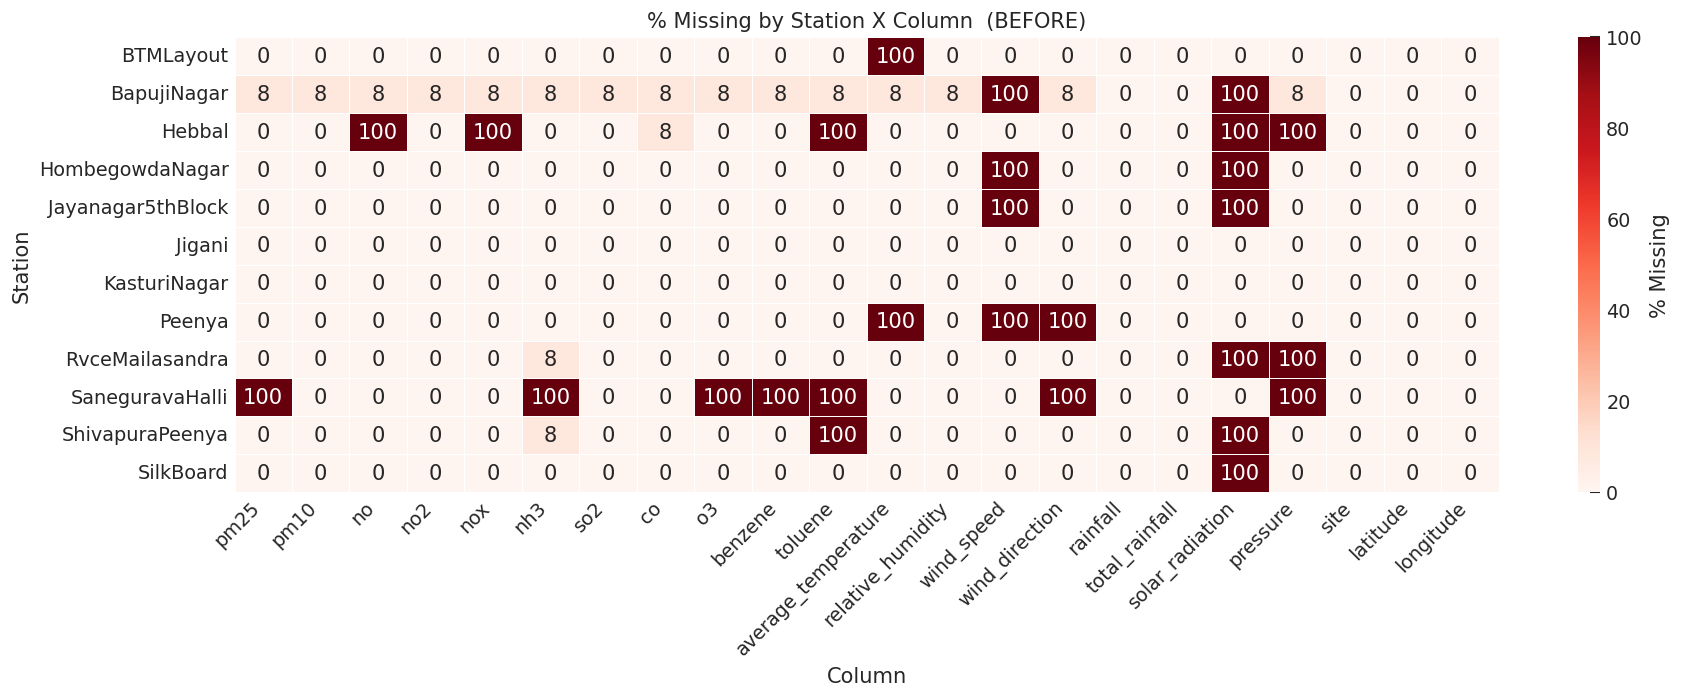

In [74]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 7 — VALUE QC (PASS 1)
# NUll values analysis
# ─────────────────────────────────────────────────────────────────────────────
def plot_missing_heatmap(df, title, save_name):
    """Station × Column heatmap of % missing. Red = 100% missing."""
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    pivot = df.groupby("station_name")[numeric_cols].apply(
        lambda g: g.isna().mean() * 100
    )
    fig, ax = plt.subplots(figsize=(max(14, len(numeric_cols) * 0.7), max(6, N * 0.5)))
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="Reds",
        vmin=0,
        vmax=100,
        linewidths=0.4,
        linecolor="white",
        annot=(pivot.shape[0] <= 20),
        fmt=".0f",
        cbar_kws={"label": "% Missing"},
    )
    ax.set_title(title)
    ax.set_xlabel("Column")
    ax.set_ylabel("Station")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fig.savefig(OUT_DIR / save_name)
    plt.show()

plot_missing_heatmap(
    df_raw,
    "% Missing by Station X Column  (BEFORE)",
    "01_missing_before_heatmap.png",
)


In [75]:
POLLUTANT = "pm10"
display(
    df_raw[[POLLUTANT, "wind_speed", "wind_direction", "solar_radiation"]]
    .isna()
    .sum()
    .to_frame("n_missing")
)

,n_missing
pm10,2976
wind_speed,140160
wind_direction,73056
solar_radiation,245280


In [76]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 8 — DIURNAL METEOROLOGICAL PROXYING & INTEGRITY CHECK
# What: 1. Discretize diurnal solar windows (Night, Morning, Afternoon, Evening).
#       2. Compute space-time neighbor medians inside these physical windows.
#       3. Broaden regional fallback to guarantee clean PG stability matrices.
# Why:  Maintains critical station network density for spatial transport equations
#       without introducing unphysical flat-line solar values across day-night boundaries.
# ─────────────────────────────────────────────────────────────────────────────

print("Initializing diurnal solar radiation fields for PG stability mapping...")
# 1. Create a deep copy of the raw dataframe to manage proxy broadcast safely
df_raw = df_raw.copy()
# 2. Extract specific hour metrics to map physical diurnal windows
hours = df_raw["time"].dt.hour

# Map standard solar positions:
# Night (20:00-05:00), Morning (06:00-11:00), Afternoon (12:00-15:00), Evening (16:00-19:00)
conditions = [
    (hours >= 6) & (hours <= 11),  # Morning
    (hours >= 12) & (hours <= 15),  # Afternoon
    (hours >= 16) & (hours <= 19),  # Evening
]
choices = ["MORNING", "AFTERNOON", "EVENING"]
df_raw["solar_window"] = np.select(conditions, choices, default="NIGHT")

# 3. Compute dynamic spatial medians conditioned on both exact time AND diurnal envelope
# This isolates any localized sensor anomalies within their correct physical time pocket
spatial_solar_map = df_raw.groupby(["time", "solar_window"])[
    "solar_radiation"
].transform("median")
df_raw["solar_radiation"] = df_raw["solar_radiation"].fillna(spatial_solar_map)

# 4. Secondary fallback: If a timestamp has 100% dead sensors network-wide,
# enforce strict, physics-based baseline constraints for the window type
window_fallbacks = {
    "NIGHT": 0.0,  # Zero radiation by default at night
    "MORNING": 150.0,  # Representative baseline sunrise/mid-morning flux (W/m²)
    "AFTERNOON": 450.0,  # Representative baseline peak insulation flux (W/m²)
    "EVENING": 75.0,  # Representative baseline sunset decay flux (W/m²)
}
for window, fallback_val in window_fallbacks.items():
    win_mask = (df_raw["solar_window"] == window) & (df_raw["solar_radiation"].isna())
    df_raw.loc[win_mask, "solar_radiation"] = fallback_val

# Drop the temporary mapping tracking column
df_raw = df_raw.drop(columns=["solar_window"])
print("✅ Diurnal solar radiation proxy alignment complete.")

Initializing diurnal solar radiation fields for PG stability mapping...
✅ Diurnal solar radiation proxy alignment complete.


In [77]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 8 — CRITICAL STATION PRUNING
# What: Drop stations that completely lack required transport matrix features.
# Why:  Prevent mathematical matrix collapse (NaN propagation) in C = T·Q.
# ─────────────────────────────────────────────────────────────────────────────

print("Evaluating station data channels for transport model requirements...")
# Define the absolute core columns needed to calculate your transport mechanics
REQUIRED_CHANNELS = ["wind_speed", "wind_direction", "solar_radiation", POLLUTANT]
stations_to_drop = []
ACTIVE_STATIONS = df_raw["station_name"].unique()

for station in ACTIVE_STATIONS:
    st_df = df_raw[df_raw["station_name"] == station]
    missing_channels = [col for col in REQUIRED_CHANNELS if st_df[col].isna().all()]
    if missing_channels:
        print(
            f"❌ Dropping station: {station:<22} | Missing channels: {missing_channels}"
        )
        stations_to_drop.append(station)
    else:
        print(f"✅ Keeping station:  {station:<22} | All core channels present.")

print("Pruning Summary")
if stations_to_drop:
    # 1. Filter out the dead stations from the long-format dataframe
    df_raw = df_raw[~df_raw["station_name"].isin(stations_to_drop)].copy()
    # 2. Crucial: Dynamically update your global lists so Block 8 stays aligned
    STATION_NAMES = [s for s in STATION_NAMES if s not in stations_to_drop]
    print(f"Dropped {len(stations_to_drop)} station(s).")
    print(f"Remaining station count: {len(STATION_NAMES)}")
else:
    print("All stations pass the channel criteria. No stations dropped.")

Evaluating station data channels for transport model requirements...
✅ Keeping station:  BTMLayout              | All core channels present.
❌ Dropping station: BapujiNagar            | Missing channels: ['wind_speed']
✅ Keeping station:  Hebbal                 | All core channels present.
❌ Dropping station: HombegowdaNagar        | Missing channels: ['wind_speed']
❌ Dropping station: Jayanagar5thBlock      | Missing channels: ['wind_speed']
✅ Keeping station:  Jigani                 | All core channels present.
✅ Keeping station:  KasturiNagar           | All core channels present.
❌ Dropping station: Peenya                 | Missing channels: ['wind_speed', 'wind_direction']
✅ Keeping station:  RvceMailasandra        | All core channels present.
❌ Dropping station: SaneguravaHalli        | Missing channels: ['wind_direction']
✅ Keeping station:  ShivapuraPeenya        | All core channels present.
✅ Keeping station:  SilkBoard              | All core channels present.
Pruning Summary

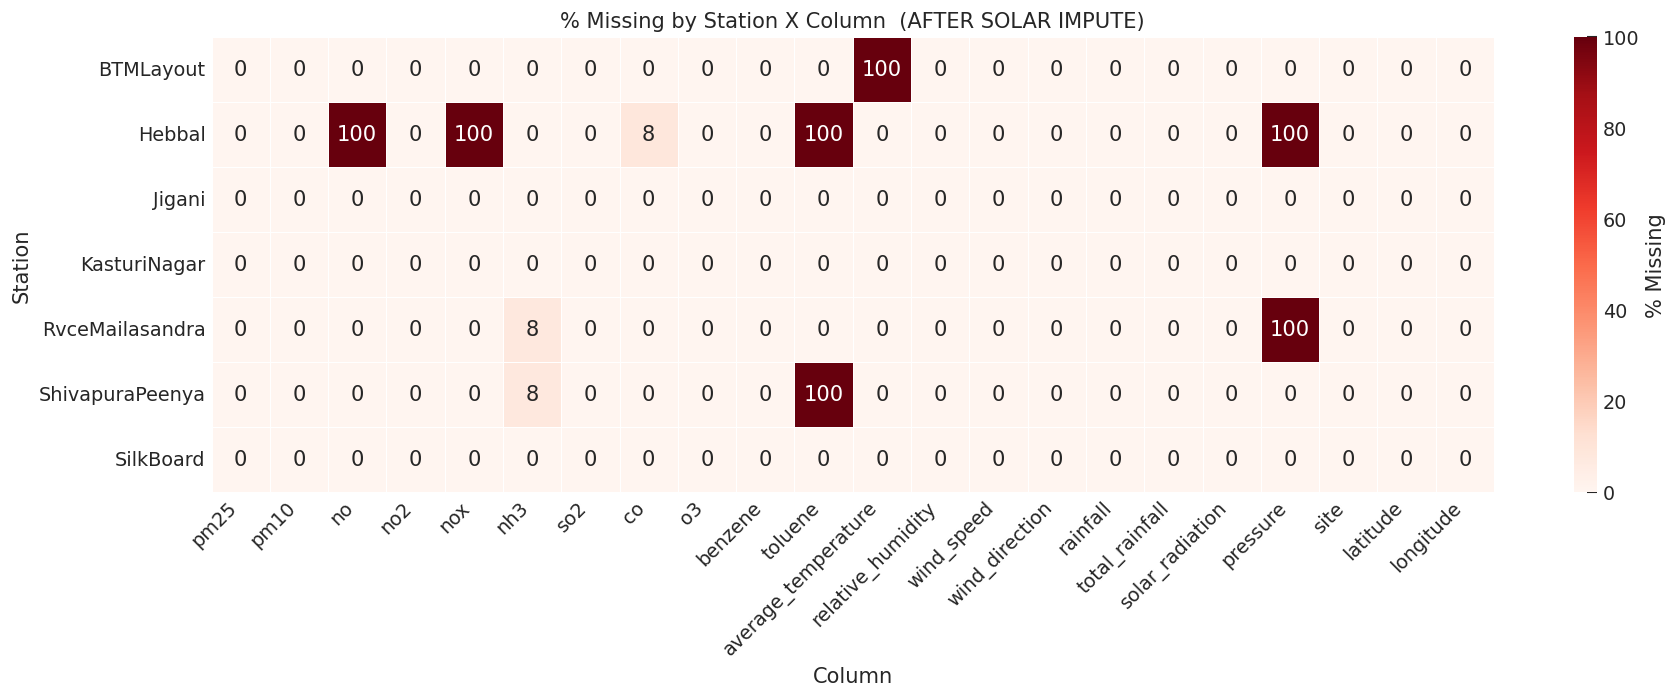

In [78]:
plot_missing_heatmap(
    df_raw,
    "% Missing by Station X Column  (AFTER SOLAR IMPUTE)",
    "02_missing_after_heatmap.png",
)

In [79]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 9 — PIVOT TO WIDE FORMAT
# What: Convert long-format (one row per station-time) to wide matrices
#       (rows = timestamps, columns = stations) for each variable.
# Why:  Vectorised operations and imputation are much faster on wide tables;
#       this shape also maps directly to the T-matrix algebra C = T·Q.
# ─────────────────────────────────────────────────────────────────────────────


def pivot_var(df: pd.DataFrame, var: str) -> pd.DataFrame:
    """Pivot a single variable from long to wide (time x station)."""
    return (
        df.pivot_table(
            index="time", columns="station_name", values=var, aggfunc="first"
        ).reindex(columns=STATION_NAMES)  # enforce consistent column order
    )


C_wide = pivot_var(df_raw, POLLUTANT)
WS_wide = pivot_var(df_raw, "wind_speed")
WD_wide = pivot_var(df_raw, "wind_direction")
SR_wide = pivot_var(df_raw, "solar_radiation")

print(f"Pivot complete.  Shape: {C_wide.shape}  (timestamps x stations)")
print("Concentration pivot — first 5 rows:")
display(C_wide.head())
print("Wind speed pivot — first 5 rows:")
display(WS_wide.head())


Pivot complete.  Shape: (35040, 7)  (timestamps x stations)
Concentration pivot — first 5 rows:


station_name,BTMLayout,Hebbal,Jigani,KasturiNagar,RvceMailasandra,ShivapuraPeenya,SilkBoard
time,,,,,,,
2025-01-01 00:00:00,85.11,98.0,108.45,42.92,69.31,121.580,125.0
2025-01-01 00:15:00,87.09,98.0,108.45,42.92,69.31,121.580,125.0
2025-01-01 00:30:00,87.09,98.0,108.45,42.92,81.81,121.580,125.0
2025-01-01 00:45:00,87.09,133.0,124.72,42.94,83.37,121.580,150.0
2025-01-01 01:00:00,91.83,133.0,126.31,43.08,83.37,114.245,150.0


Wind speed pivot — first 5 rows:


station_name,BTMLayout,Hebbal,Jigani,KasturiNagar,RvceMailasandra,ShivapuraPeenya,SilkBoard
time,,,,,,,
2025-01-01 00:00:00,0.99,0.5,5.50,1.57,2.31,0.46,0.8
2025-01-01 00:15:00,1.02,0.6,5.87,1.56,2.71,0.46,1.2
2025-01-01 00:30:00,0.92,0.5,5.51,1.48,2.41,0.46,1.0
2025-01-01 00:45:00,0.93,0.5,5.50,1.50,2.44,0.46,1.3
2025-01-01 01:00:00,0.96,0.5,5.20,1.41,2.45,0.41,1.1


# Until above code everything is analysed -- I have tried my best to impute data logically , but as we See -- Imputation in itself is not a correct method
# If I dont do solar imputation, then it was  only 3 stations ,...

In [80]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 10 — DERIVE STABILITY CLASSES  (n_times x N)
# What: For every (timestamp, station) pair, assign a Pasquill-Gifford stability
#       class based on local wind speed, solar radiation and time-of-day.
# Why:  Each station sees different wind conditions; a single global class
#       would incorrectly homogenise the T matrix across the network.
# ─────────────────────────────────────────────────────────────────────────────
N = len(STATION_NAMES) # Now it has dropped from 14 to 7

times = C_wide.index  # DatetimeIndex
hours = times.hour  # 0–23 integer array
is_daytime = (hours >= 6) & (hours < 18)
n_times = len(times)

print(f"Time axis:  {n_times:,} timestamps  ({times[0].date()} → {times[-1].date()})")
print(f"Day windows  : {is_daytime.sum():,}")
print(f"Night windows: {(~is_daytime).sum():,}")

# (n_times, N) object array of stability class strings
STAB_classes = np.empty((n_times, N), dtype=object)
for t_idx in tqdm(range(n_times), desc="Stability classes", unit="ts"):
    day = bool(is_daytime[t_idx])
    for s_idx in range(N):
        STAB_classes[t_idx, s_idx] = stability_class(
            wind_speed_ms=WS_wide.iat[t_idx, s_idx],
            solar_rad_Wm2=SR_wide.iat[t_idx, s_idx],
            is_daytime=day,
        )

flat = STAB_classes.flatten()
counts = Counter(flat)
total = len(flat)

print("Stability class distribution (all stations x all times):")
for cls in ["A", "B", "C", "D", "E", "F"]:
    pct = counts.get(cls, 0) / total * 100
    bar = "█" * int(pct / 2)
    print(f"  {cls}: {bar:<30s} {pct:5.1f}%")


Time axis:  35,040 timestamps  (2025-01-01 → 2025-12-31)
Day windows  : 17,520
Night windows: 17,520


Stability classes:   0%|          | 0/35040 [00:00<?, ?ts/s]

Stability class distribution (all stations x all times):
  A: █                                3.2%
  B: ████                             8.2%
  C: ██████████████████              37.5%
  D: █                                3.0%
  E:                                  1.8%
  F: ███████████████████████         46.2%


In [81]:
#  F means moderately stable
#  A means turbulence

In [82]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 11 — BUILD T(t): THE 3-D TRANSPORT TENSOR
# What: T_tensor[t, i, j] = transport coefficient from source j to receptor i
#       at timestamp t, given local wind conditions.
# Why:  A single-snapshot T matrix (notebook 1 approach) misses diurnal and
#       seasonal transport variability.  The tensor captures the full picture.
# Complexity: n_times x N x N Gaussian-plume evaluations.
# ─────────────────────────────────────────────────────────────────────────────

# Pre-allocate in float32 to halve memory vs float64
T_tensor = np.zeros((n_times, N, N), dtype=np.float32)

print(f"Building T tensor: {n_times:,} timestamps x {N} x {N} …")
print(f"Memory footprint  : {T_tensor.nbytes / 1e6:.1f} MB")

for t_idx in tqdm(range(n_times), desc="Building T(t)", unit="ts"):
    ws_t = WS_wide.iloc[t_idx].values
    wd_t = WD_wide.iloc[t_idx].values
    stab_t = STAB_classes[t_idx]

    for j in range(N):  # source station index
        for i in range(N):  # receptor station index
            T_tensor[t_idx, i, j] = transport_element(
                lat_src=LATS[j],
                lon_src=LONS[j],
                lat_rec=LATS[i],
                lon_rec=LONS[i],
                wind_speed_ms=ws_t[j],
                wind_dir_deg=wd_t[j],
                stability_cls=stab_t[j],
                H_m=H_STACK,
            )

print("T tensor complete.")
print(f"- Shape        : {T_tensor.shape}")
print(f"- Non-zero     : {(T_tensor > 0).sum():,}")
print(f"- Max value    : {T_tensor.max():.4f}  µg m⁻³ per g s⁻¹")
print(f"- Mean non-zero: {T_tensor[T_tensor > 0].mean():.6f}")


Building T tensor: 35,040 timestamps x 7 x 7 …
Memory footprint  : 6.9 MB


Building T(t):   0%|          | 0/35040 [00:00<?, ?ts/s]

T tensor complete.
- Shape        : (35040, 7, 7)
- Non-zero     : 362,277
- Max value    : 432.2509  µg m⁻³ per g s⁻¹
- Mean non-zero: 1.642778


In [83]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 12 — SNAPSHOT T MATRIX (single-timestamp, for classical solver)
# What: Extract one representative T matrix from the tensor and the matching
#       observed concentration vector C_obs.
# Why:  The classical solver (notebook 2) solves C = T·Q at a fixed instant.
#       We pick the earliest timestamp where all N stations have valid data.
# ─────────────────────────────────────────────────────────────────────────────

# Find the first timestamp where every station has a concentration value
full_mask = C_wide.notna().all(axis=1)
full_times = C_wide.index[full_mask]

if len(full_times) > 0:
    t0 = full_times[0]
else:
    t0 = times[0]

t0_idx = list(times).index(t0)
T_matrix = T_tensor[t0_idx]  # (N, N) float32
C_obs = C_wide.loc[t0].values.astype(float)

# Observed met conditions at snapshot time
WS_snap = WS_wide.loc[t0].values
WD_snap = WD_wide.loc[t0].values
SR_snap = SR_wide.loc[t0].values

print(f"Snapshot time : {t0}")
print(f"T_matrix shape: {T_matrix.shape}")

df_T_peek = pd.DataFrame(
    T_matrix,
    index=STATION_NAMES,
    columns=STATION_NAMES,
)
print("First block of T  [µg m⁻³ per g s⁻¹]:")
display(df_T_peek)
print(f"C_obs ({POLLUTANT}) per station [µg m⁻³]:")
df_c = pd.DataFrame({"station": STATION_NAMES, "C_obs": C_obs})
display(df_c)


Snapshot time : 2025-01-01 00:00:00
T_matrix shape: (7, 7)
First block of T  [µg m⁻³ per g s⁻¹]:


,BTMLayout,Hebbal,Jigani,KasturiNagar,RvceMailasandra,ShivapuraPeenya,SilkBoard
BTMLayout,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0
Hebbal,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0
Jigani,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0
KasturiNagar,0.0,0.00004,0.000000,0.000000,0.0,0.0,0.0
RvceMailasandra,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0
ShivapuraPeenya,0.0,0.00000,0.000000,0.000000,0.0,0.0,0.0
SilkBoard,0.0,0.00000,0.120292,0.013842,0.0,0.0,0.0


C_obs (pm10) per station [µg m⁻³]:


,station,C_obs
0,BTMLayout,85.11
1,Hebbal,98.00
2,Jigani,108.45
3,KasturiNagar,42.92
4,RvceMailasandra,69.31
5,ShivapuraPeenya,121.58
6,SilkBoard,125.00


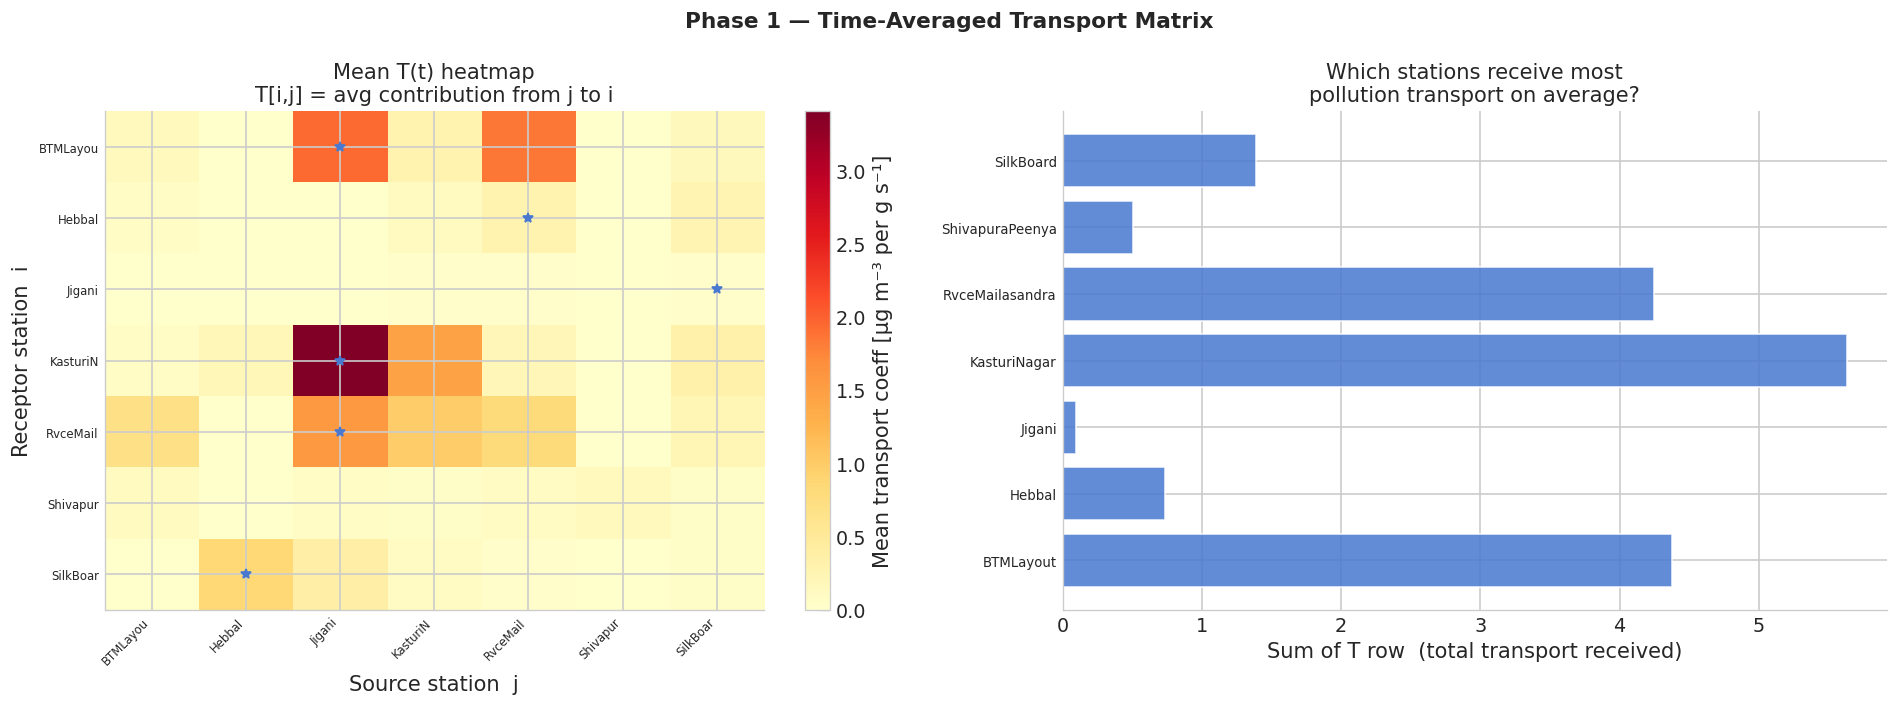

Saved: /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/data_prep/fig_T_mean_heatmap.png


In [84]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 13 — VISUALISE: MEAN TRANSPORT MAP & RECEPTOR INFLUENCE
# What: Average T over time → heatmap of typical transport pathways.
# Why:  Bright T[i,j] = station j is a consistent contributor to station i;
#       useful for identifying dominant source–receptor pairs at a glance.
# ─────────────────────────────────────────────────────────────────────────────

T_mean = T_tensor.mean(axis=0)   # (N, N)
short_names = [s[:8] for s in STATION_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: time-averaged T heatmap 
ax = axes[0]
im = ax.imshow(T_mean, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax, label="Mean transport coeff [µg m⁻³ per g s⁻¹]")
ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(short_names, fontsize=7)
ax.set_xlabel("Source station  j")
ax.set_ylabel("Receptor station  i")
ax.set_title("Mean T(t) heatmap\nT[i,j] = avg contribution from j to i")

# Star = dominant source for each receptor
for i in range(N):
    j_max = T_mean[i].argmax()
    if j_max != i:
        ax.plot(j_max, i, "b*", ms=6)

# Right: total transport received per station 
ax2 = axes[1]
total_inflow = T_mean.sum(axis=1)
y_pos = np.arange(N)
ax2.barh(y_pos, total_inflow, color=PALETTE[0], alpha=0.85)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(STATION_NAMES, fontsize=8)
ax2.set_xlabel("Sum of T row  (total transport received)")
ax2.set_title("Which stations receive most\npollution transport on average?")

plt.suptitle("Phase 1 — Time-Averaged Transport Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_T_mean_heatmap.png")
plt.show()
print(f"Saved: {OUT_DIR / 'fig_T_mean_heatmap.png'}")


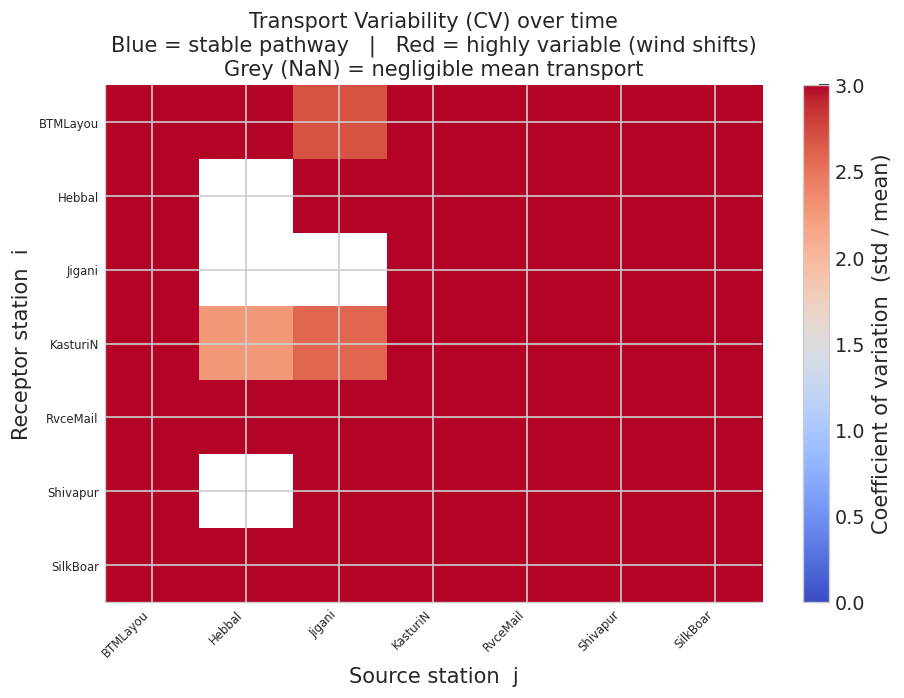

Saved: /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/data_prep/fig_T_variability.png


In [85]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 14 — TRANSPORT VARIABILITY: COEFFICIENT OF VARIATION
# What: CV = std(T[i,j]) / mean(T[i,j]) across time.
# Why:  High CV → wind regularly shifts direction → unreliable source-receptor link.
#       Low CV  → stable transport pathway → high confidence source attribution.
# ─────────────────────────────────────────────────────────────────────────────

T_std = T_tensor.std(axis=0)
T_cv = np.where(T_mean > 1e-9, T_std / T_mean, np.nan)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(T_cv, cmap="coolwarm", vmin=0, vmax=3, aspect="auto")
plt.colorbar(im, ax=ax, label="Coefficient of variation  (std / mean)")
ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(short_names, fontsize=7)
ax.set_xlabel("Source station  j")
ax.set_ylabel("Receptor station  i")
ax.set_title(
    "Transport Variability (CV) over time\n"
    "Blue = stable pathway   |   Red = highly variable (wind shifts)\n"
    "Grey (NaN) = negligible mean transport"
)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_T_variability.png")
plt.show()
print(f"Saved: {OUT_DIR / 'fig_T_variability.png'}")

Transport graph: 7 nodes, 42 edges


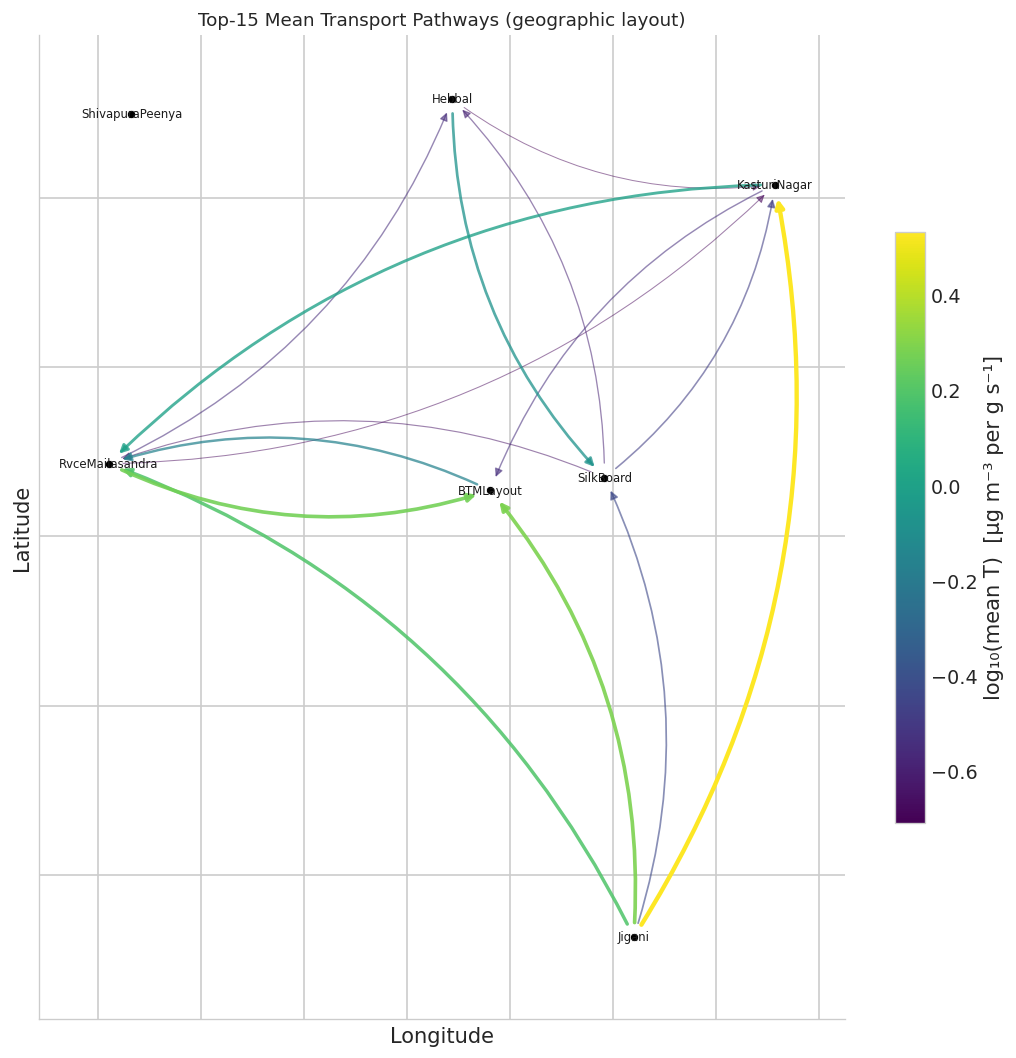

Saved: /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/data_prep/fig_transport_graph.png


In [86]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 15 — TRANSPORT GRAPH: TOP-15 PATHWAYS
# What: Build a directed graph of mean transport; draw the 15 strongest edges.
# Why:  The heatmap shows magnitude; the graph shows *directionality* —
#       which stations are net sources vs. net receptors in geographic space.
# ─────────────────────────────────────────────────────────────────────────────

# Build directed graph using time-averaged T
G = nx.DiGraph()
for i, rec in enumerate(STATION_NAMES):
    for j, src in enumerate(STATION_NAMES):
        if i != j and T_mean[i, j] > 0:
            G.add_edge(src, rec, weight=T_mean[i, j])

print(f"Transport graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Geographic node positions
pos = {
    row["station_name"]: (row["longitude"], row["latitude"])
    for _, row in stations_df.iterrows()
}

# Gather log-scaled edge weights and sort
all_edges   = [(u, v) for u, v, _ in G.edges(data=True)]
all_weights = np.array([math.log10(G[u][v]["weight"]) for u, v in all_edges])
sort_idx    = np.argsort(all_weights)

TOP_N        = 15
edges_plot   = [all_edges[i]   for i in sort_idx[-TOP_N:]]
weights_plot = all_weights[sort_idx[-TOP_N:]]

norm  = mcolors.Normalize(vmin=weights_plot.min(), vmax=weights_plot.max())
cmap  = plt.cm.viridis

fig, ax = plt.subplots(figsize=(9, 9))

for (u, v), w in zip(edges_plot, weights_plot):
    lw    = 0.6 + 2.0 * norm(w)
    alpha = 0.50 + 0.50 * norm(w)
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)],
        edge_color=[cmap(norm(w))], width=lw, alpha=alpha,
        arrows=True, arrowsize=10, arrowstyle="-|>",
        connectionstyle="arc3,rad=0.20", ax=ax,
        min_source_margin=7, min_target_margin=7,
    )

nx.draw_networkx_nodes(G, pos, node_size=25, node_color="#000000",
                       edgecolors="#ffffff", linewidths=0.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="log₁₀(mean T)  [µg m⁻³ per g s⁻¹]", shrink=0.6)

ax.set_title(f"Top-{TOP_N} Mean Transport Pathways (geographic layout)", fontsize=11)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_transport_graph.png")
plt.show()
print(f"Saved: {OUT_DIR / 'fig_transport_graph.png'}")


In [87]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 17 — SAVE ARTEFACTS
# What: Persist all computed arrays to disk as parquet (DataFrames) or npy
#       (numpy tensor).  Column/index names are preserved for downstream use.
# Why:  Parquet keeps dtype, index name, and column labels — future notebooks
#       can load and manipulate without re-specifying schema.
# ─────────────────────────────────────────────────────────────────────────────

# 3-D tensor (numpy binary — fast, exact, no schema needed)
np.save(OUT_DIR / "T_tensor.npy", T_tensor)
print(f"T_tensor.npy       {T_tensor.nbytes / 1e6:.1f} MB  {T_tensor.shape}")

# Snapshot T matrix as parquet (stations as both index and columns)
df_T_snap = pd.DataFrame(
    T_matrix.astype(np.float64),
    index=pd.Index(STATION_NAMES, name="receptor_station"),
    columns=pd.Index(STATION_NAMES, name="source_station"),
)
df_T_snap.to_parquet(OUT_DIR / "T_matrix_snapshot.parquet")
print(f"T_matrix_snapshot.parquet  {df_T_snap.shape}")

# Snapshot C_obs as parquet
df_C_snap = pd.DataFrame({"C_obs": C_obs, "station_name": STATION_NAMES}).set_index(
    "station_name"
)
df_C_snap.index.name = "station_name"
df_C_snap.to_parquet(OUT_DIR / "C_obs_snapshot.parquet")
print(f"C_obs_snapshot.parquet     {df_C_snap.shape}")

# Filled wide matrices
for df, fname in [
    (C_wide, "C_matrix.parquet"),
    (WS_wide, "WS_matrix.parquet"),
    (WD_wide, "WD_matrix.parquet"),
    (SR_wide, "SR_matrix.parquet"),
]:
    df.columns.name = "station_name"
    df.index.name = "time"
    df.to_parquet(OUT_DIR / fname)
    print(f"{fname:<30s} {df.shape}")

# Stability class DataFrame
stab_df = pd.DataFrame(
    STAB_classes,
    index=pd.Index(times, name="time"),
    columns=pd.Index(STATION_NAMES, name="station_name"),
)
stab_df.to_parquet(OUT_DIR / "stability_classes.parquet")
print(f"stability_classes.parquet  {stab_df.shape}")

# Meta DataFrame
meta_df = pd.DataFrame(
    {
        "hour": hours,
        "is_daytime": is_daytime,
        "n_valid_C": C_wide.notna().sum(axis=1).values,
        "snapshot_t0": [t == t0 for t in times],
    },
    index=pd.Index(times, name="time"),
)
meta_df.to_parquet(OUT_DIR / "meta.parquet")
print(f"meta.parquet               {meta_df.shape}")

# Station metadata
stations_df.to_parquet(OUT_DIR / "stations.parquet", index=False)
print(f"stations.parquet           {stations_df.shape}")


print("PHASE 1 SUMMARY")
print(f"- Timestamps       : {n_times:,}")
print(f"- Stations         : {N}  (excluded: {EXCLUDE_STATIONS})")
print(f"- Pollutant        : {POLLUTANT}")
print(f"- T tensor shape   : {T_tensor.shape}")
print(f"- T tensor memory  : {T_tensor.nbytes / 1e6:.1f} MB")
print(f"- Date range       : {times[0].date()} → {times[-1].date()}")
print(f"- Snapshot time t0 : {t0}")
dominant = Counter(STAB_classes.flatten()).most_common(1)[0]
print(f"- Dominant stab.   : {dominant[0]}  ({dominant[1]:,} entries)")
print(f"- Output dir       : {OUT_DIR}")


T_tensor.npy       6.9 MB  (35040, 7, 7)
T_matrix_snapshot.parquet  (7, 7)
C_obs_snapshot.parquet     (7, 1)
C_matrix.parquet               (35040, 7)
WS_matrix.parquet              (35040, 7)
WD_matrix.parquet              (35040, 7)
SR_matrix.parquet              (35040, 7)
stability_classes.parquet  (35040, 7)
meta.parquet               (35040, 4)
stations.parquet           (12, 6)
PHASE 1 SUMMARY
- Timestamps       : 35,040
- Stations         : 7  (excluded: ['BWSSBKadabesanahalli', 'CityRailwayStation'])
- Pollutant        : pm10
- T tensor shape   : (35040, 7, 7)
- T tensor memory  : 6.9 MB
- Date range       : 2025-01-01 → 2025-12-31
- Snapshot time t0 : 2025-01-01 00:00:00
- Dominant stab.   : F  (113,277 entries)
- Output dir       : /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/data_prep
